Baseline Text Classification.ipynb

Author: Jorge Luis Rosas Trigueros

Last modification: 12 apr 26

https://tinyurl.com/277f6wph

In [1]:
#====================================#
# 1. Install and import dependencies
#====================================#
!pip install -q datasets

from datasets import load_dataset, concatenate_datasets

#====================================#
# 2. Load IMDB dataset
#====================================#
imdb = load_dataset("imdb")

# imdb["train"] → 25,000 reviews
# imdb["test"]  → 25,000 reviews

#====================================#
# 3. Combine train and test into one corpus
#====================================#
full_dataset = concatenate_datasets([
    imdb["train"],
    imdb["test"]
])

print("Total corpus size:", len(full_dataset))  # 50,000

#====================================#
# 4. Split into Train (80%) and Temp (40%)
#====================================#
split_1 = full_dataset.train_test_split(
    test_size=0.4,
    seed=42,
    shuffle=True
)

train_set = split_1["train"]      # 80%
temp_set  = split_1["test"]       # 40%

#====================================#
# 5. Split Temp into Dev (20%) and Test (20%)
#====================================#
split_2 = temp_set.train_test_split(
    test_size=0.5,
    seed=42,
    shuffle=True
)

dev_set  = split_2["train"]       # 20%
test_set = split_2["test"]        # 20%

#====================================#
# 6. Sanity checks
#====================================#
print(f"Training set size:    {len(train_set)}")
print(f"Development set size: {len(dev_set)}")
print(f"Test set size:        {len(test_set)}")

#====================================#
# 7. Example review
#====================================#
example = train_set[0]
print("\nSample review text:\n")
print(example["text"][:500])
print("\nLabel:", example["label"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Total corpus size: 50000
Training set size:    30000
Development set size: 10000
Test set size:        10000

Sample review text:

Serge Farnel made a very precise critics of this film in the revue "The Rwandese night" (www.lanuitrwandaise.net)<br /><br />A critics which shows how France was behind all the situation undergone by the United Nations in Rwanda.<br /><br />The UN soldiers were in a dangerous situation while the french soldiers were warmly welcomed by the genocide forces.<br /><br />The day before, ten UN soldiers had been killed by the genocide forces.<br /><br />That is why the UN soldiers decided to protect t

Label: 0


In [2]:
positive_lexicon = {
    'good', 'great', 'excellent', 'amazing', 'wonderful',
    'love', 'loved', 'like', 'liked',
    'fantastic', 'best', 'enjoyed', 'positive', 'happy'
}

negative_lexicon = {
    'bad', 'terrible', 'awful', 'boring', 'worst',
    'hate', 'hated', 'disappointing', 'poor',
    'negative', 'sad', 'waste'
}

pronouns_1st_2nd = {
    'i', 'me', 'my', 'mine', 'we', 'us', 'our', 'ours',
    'you', 'your', 'yours'
}


In [3]:
import numpy as np
import math

def extract_features(text):
    tokens = text.lower().split()
    length = len(tokens) if len(tokens) > 0 else 1

    # x1: number of positive words
    x1 = sum(1 for w in tokens if w in positive_lexicon)

    # x2: number of negative words
    x2 = sum(1 for w in tokens if w in negative_lexicon)

    # x3: presence of the word "no"
    x3 = 1 if "no" in tokens else 0

    # x4: count of 1st- and 2nd-person pronouns
    x4 = sum(1 for w in tokens if w in pronouns_1st_2nd)

    # x5: presence of "!"
    x5 = 1 if "!" in text else 0

    # x6: logarithm of document length
    x6 = math.log(length)

    return np.array([x1, x2, x3, x4, x5, x6])

In [4]:
X_train = np.array([extract_features(ex["text"]) for ex in train_set])
X_dev   = np.array([extract_features(ex["text"]) for ex in dev_set])

In [5]:
train_mean = X_train.mean(axis=0)
train_std  = X_train.std(axis=0) + 1e-8  # numerical stability

In [6]:
X_train_norm = (X_train - train_mean) / train_std
X_dev_norm   = (X_dev   - train_mean) / train_std

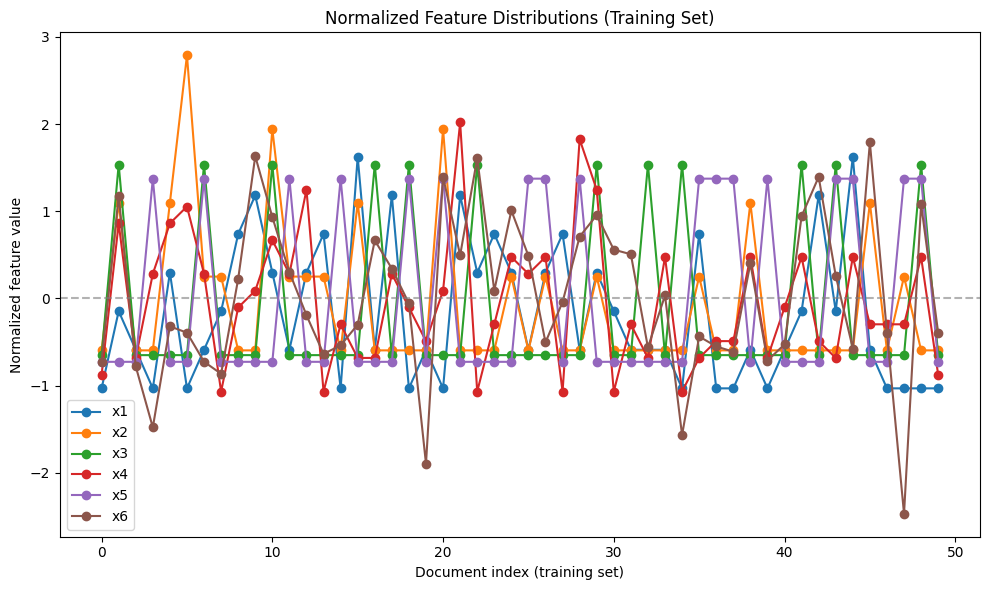

In [7]:
import matplotlib.pyplot as plt

feature_names = ['x1', 'x2', 'x3', 'x4', 'x5', 'x6']

plt.figure(figsize=(10, 6))
for i in range(X_train_norm.shape[1]):
    plt.plot(X_train_norm[:50, i], marker='o', label=feature_names[i])

plt.axhline(0, linestyle='--', color='gray', alpha=0.6)
plt.xlabel('Document index (training set)')
plt.ylabel('Normalized feature value')
plt.title('Normalized Feature Distributions (Training Set)')
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
import numpy as np

# Select a tiny subset for illustration
X = X_train_norm[:3]        # shape: (3, 6)
y = np.array([train_set[i]["label"] for i in range(3)])

print("Feature matrix X:")
print(X)
print("\nLabels y:")
print(y)


Feature matrix X:
[[-1.03222692 -0.59628317 -0.65091488 -0.87625518 -0.72773463 -0.72661473]
 [-0.14652468  1.09690141  1.53629911  0.86106967 -0.72773463  1.17701928]
 [-0.5893758  -0.59628317 -0.65091488 -0.68321908 -0.72773463 -0.78059314]]

Labels y:
[0 1 1]


In [9]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [10]:
# Number of features
n_features = X.shape[1]

# Parameter vector θ
theta = np.zeros(n_features)

# Learning rate η
eta = 0.5

print("Initial theta:", theta)

Initial theta: [0. 0. 0. 0. 0. 0.]


In [11]:
num_iterations = 2

for iteration in range(num_iterations):
    print(f"\n=== Iteration {iteration + 1} ===")

    for i in range(len(X)):
        x_i = X[i]
        y_i = y[i]

        # Forward pass
        z = np.dot(theta, x_i)
        y_hat = sigmoid(z)

        # Error term
        error = y_i - y_hat

        # Gradient update
        theta = theta + eta * error * x_i

        # Logging (mirrors the book)
        print(f"\nExample {i + 1}")
        print("x_i =", np.round(x_i, 4))
        print("y_i =", y_i)
        print("z =", round(float(z), 4))
        print("ŷ =", round(float(y_hat), 4))
        print("error =", round(float(error), 4))
        print("Updated theta =", np.round(theta, 4))


=== Iteration 1 ===

Example 1
x_i = [-1.0322 -0.5963 -0.6509 -0.8763 -0.7277 -0.7266]
y_i = 0
z = 0.0
ŷ = 0.5
error = -0.5
Updated theta = [0.2581 0.1491 0.1627 0.2191 0.1819 0.1817]

Example 2
x_i = [-0.1465  1.0969  1.5363  0.8611 -0.7277  1.177 ]
y_i = 1
z = 0.6457
ŷ = 0.6561
error = 0.3439
Updated theta = [0.2329 0.3377 0.4269 0.3671 0.0568 0.3841]

Example 3
x_i = [-0.5894 -0.5963 -0.6509 -0.6832 -0.7277 -0.7806]
y_i = 1
z = -1.2085
ŷ = 0.23
error = 0.77
Updated theta = [ 0.0059  0.1081  0.1763  0.1041 -0.2234  0.0835]

=== Iteration 2 ===

Example 1
x_i = [-1.0322 -0.5963 -0.6509 -0.8763 -0.7277 -0.7266]
y_i = 0
z = -0.1747
ŷ = 0.4564
error = -0.4564
Updated theta = [ 0.2415  0.2442  0.3249  0.3041 -0.0573  0.2494]

Example 2
x_i = [-0.1465  1.0969  1.5363  0.8611 -0.7277  1.177 ]
y_i = 1
z = 1.3286
ŷ = 0.7906
error = 0.2094
Updated theta = [ 0.2262  0.3591  0.4857  0.3942 -0.1335  0.3726]

Example 3
x_i = [-0.5894 -0.5963 -0.6509 -0.6832 -0.7277 -0.7806]
y_i = 1
z = -1.1266
ŷ 

In [12]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score

y_train = train_set["label"]
y_dev   = dev_set["label"]

In [13]:
len(X_train_norm)

30000

In [14]:
n_features = X_train_norm.shape[1]
theta = np.zeros(n_features)   # parameters
eta = 0.1                      # learning rate
epochs = 5                     # small on purpose (illustration)

loss_history = []
theta_history = []

for epoch in range(epochs):
    total_loss = 0.0

    for x_i, y_i in zip(X_train_norm, y_train):
        z = np.dot(theta, x_i)
        y_hat = sigmoid(z)

        # Cross-entropy loss
        loss = -(y_i * np.log(y_hat + 1e-8) +
                 (1 - y_i) * np.log(1 - y_hat + 1e-8))
        total_loss += loss

        # Gradient ascent on log-likelihood
        error = y_i - y_hat
        theta += eta * error * x_i

    avg_loss = total_loss / len(X_train_norm)
    loss_history.append(avg_loss)
    theta_history.append(theta.copy())

    print(f"Epoch {epoch+1}: average loss = {avg_loss:.16f}")

Epoch 1: average loss = 0.6133728623381403
Epoch 2: average loss = 0.6133522003590941
Epoch 3: average loss = 0.6133522003590941
Epoch 4: average loss = 0.6133522003590941
Epoch 5: average loss = 0.6133522003590941


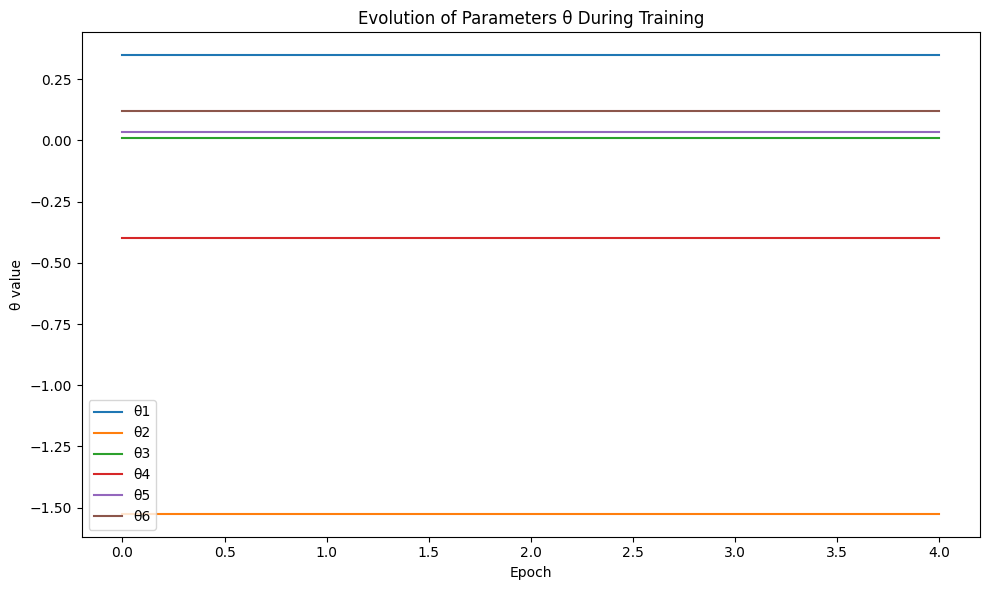

In [15]:
theta_history = np.array(theta_history)

plt.figure(figsize=(10, 6))
for j in range(n_features):
    plt.plot(theta_history[:, j], label=f"θ{j+1}")

plt.xlabel("Epoch")
plt.ylabel("θ value")
plt.title("Evolution of Parameters θ During Training")
plt.legend()
plt.tight_layout()
plt.show()

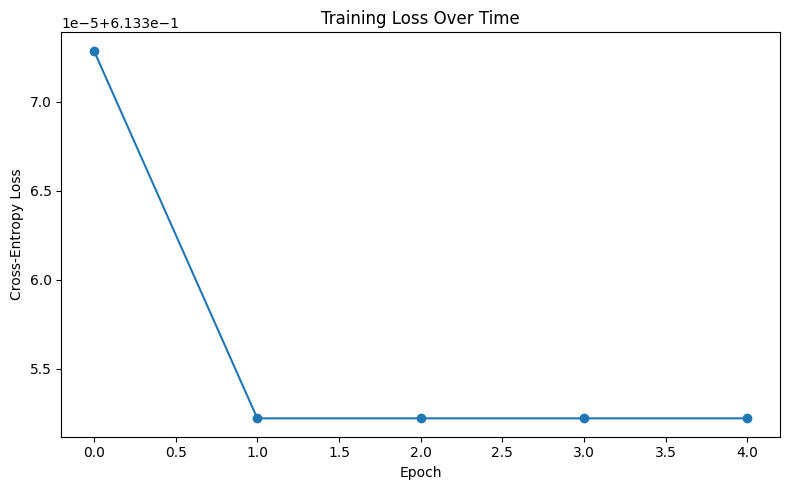

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training Loss Over Time")
plt.tight_layout()
plt.show()

In [17]:
def predict(X, theta):
    probs = sigmoid(X @ theta)
    return (probs >= 0.5).astype(int)

In [18]:
y_dev_pred = predict(X_dev_norm, theta)

In [19]:
cm = confusion_matrix(y_dev, y_dev_pred)

In [20]:
#         Predicted − Predicted +

# Actual −   TN         FP

# Actual +   FN         TP

In [21]:
precision = precision_score(y_dev, y_dev_pred)
recall    = recall_score(y_dev, y_dev_pred)
accuracy  = accuracy_score(y_dev, y_dev_pred)

precision, recall, accuracy

(0.6553680981595092, 0.8366947327197963, 0.6919)

In [22]:
# Feature ablation: Remove feature x5 (column index 4)
X_train_ab = np.delete(X_train_norm, 5, axis=1)
X_dev_ab   = np.delete(X_dev_norm,   5, axis=1)

print("Original feature size:", X_train_norm.shape[1])
print("Ablated feature size:", X_train_ab.shape[1])

Original feature size: 6
Ablated feature size: 5


In [23]:
theta_ab = np.zeros(X_train_ab.shape[1])
eta = 0.1
epochs = 5

loss_history_ab = []

for epoch in range(epochs):
    total_loss = 0.0

    for x_i, y_i in zip(X_train_ab, y_train):
        z = np.dot(theta_ab, x_i)
        y_hat = sigmoid(z)

        loss = -(y_i * np.log(y_hat + 1e-8) +
                 (1 - y_i) * np.log(1 - y_hat + 1e-8))
        total_loss += loss

        error = y_i - y_hat
        theta_ab += eta * error * x_i

    avg_loss = total_loss / len(X_train_ab)
    loss_history_ab.append(avg_loss)

    print(f"[Ablated] Epoch {epoch+1}: loss = {avg_loss:.4f}")


[Ablated] Epoch 1: loss = 0.6073
[Ablated] Epoch 2: loss = 0.6072
[Ablated] Epoch 3: loss = 0.6072
[Ablated] Epoch 4: loss = 0.6072
[Ablated] Epoch 5: loss = 0.6072


In [24]:
def predict_ab(X, theta):
    return (sigmoid(X @ theta) >= 0.5).astype(int)

y_dev_pred_ab = predict_ab(X_dev_ab, theta_ab)

cm_ab = confusion_matrix(y_dev, y_dev_pred_ab)
precision_ab = precision_score(y_dev, y_dev_pred_ab)
recall_ab = recall_score(y_dev, y_dev_pred_ab)
accuracy_ab = accuracy_score(y_dev, y_dev_pred_ab)

cm_ab, precision_ab, recall_ab, accuracy_ab

(array([[2658, 2235],
        [ 846, 4261]]),
 0.655942118226601,
 0.8343450166438222,
 0.6919)

In [25]:
# Build test feature matrix and labels
X_test = np.array([extract_features(test_set[i]["text"])
                   for i in range(len(test_set))])
y_test = np.array(test_set["label"])

# Normalize using TRAINING statistics
X_test_norm = (X_test - train_mean) / train_std

In [26]:
y_test_pred = predict(X_test_norm, theta)

In [27]:
cm_test = confusion_matrix(y_test, y_test_pred)

In [28]:
precision_test = precision_score(y_test, y_test_pred)
recall_test    = recall_score(y_test, y_test_pred)
accuracy_test  = accuracy_score(y_test, y_test_pred)

precision_test, recall_test, accuracy_test

(0.6495334493120354, 0.8205794205794206, 0.6886)

# SVM

In [29]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score

In [30]:
svm_clf = SVC(kernel="linear", probability=True, random_state=42)
svm_clf.fit(X_train_norm, y_train)

SVC(kernel='linear', probability=True, random_state=42)

In [31]:
y_test_pred_svm = svm_clf.predict(X_test_norm)

In [32]:
cm_svm = confusion_matrix(y_test, y_test_pred_svm)
cm_svm

array([[2741, 2254],
       [ 790, 4215]])

In [33]:
accuracy_svm = accuracy_score(y_test, y_test_pred_svm)
recall_svm   = recall_score(y_test, y_test_pred_svm)

accuracy_svm, recall_svm

(0.6956, 0.8421578421578422)

# ROC Curve
ROC stands for Receiver Operating Characteristic.


In [34]:
y_test_probs_svm = svm_clf.predict_proba(X_test_norm)[:, 1]

In [35]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr_svm, tpr_svm, _ = roc_curve(y_test, y_test_probs_svm)
auc_svm = roc_auc_score(y_test, y_test_probs_svm)

auc_svm

np.float64(0.7674802474802475)

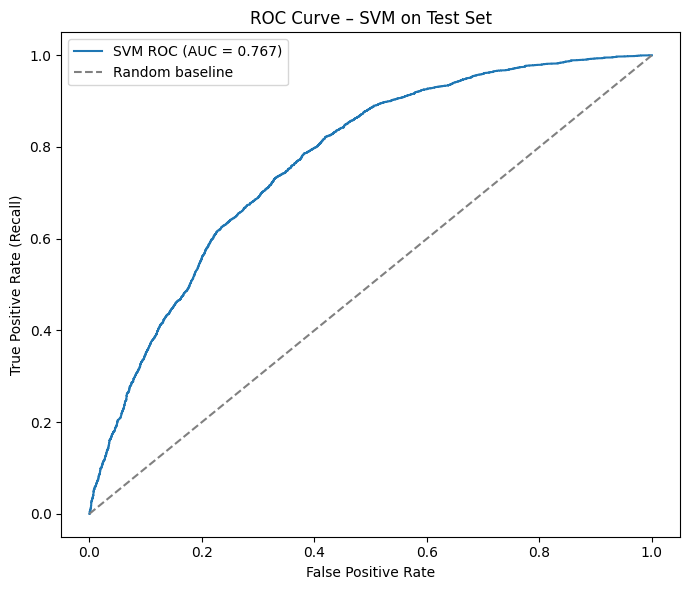

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))
plt.plot(fpr_svm, tpr_svm, label=f"SVM ROC (AUC = {auc_svm:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random baseline")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve – SVM on Test Set")
plt.legend()
plt.tight_layout()
plt.show()

What ROC answers

How well does the model separate positive and negative reviews independently of a fixed threshold?

Key points

* Top‑left corner → high recall, few false positives


* Diagonal line → random guessing
* AUC (Area Under Curve):

* * 1.0 → perfect separation
* *  0.5 → no discrimination


Practical use

Choose a threshold depending on whether you prefer:

* fewer false positives (move right → left)
* fewer missed positives (move down → up)